# EuroSAT Land Use and Land Cover Classification

**Group Members:** Xiao Yu, Qianmu Zheng, Jinyang Xu  
**Submission Date:** 2026/3/31

---

In this assignment, we explore land use and land cover classification using the EuroSAT dataset, comparing traditional machine learning approaches (SVM, Random Forest) with deep learning models (fully connected networks, CNNs, and transfer learning).

## 0. Environment Setup

In [1]:
# Core libraries
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Image processing
from PIL import Image

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.svm import SVC

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model, to_categorical

# Multispectral
import tifffile

# output
#os.makedirs("eurosat_files", exist_ok=True)

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU available: False


---
## 1. Data Loading, Processing, and Exploration

### 1.1 Data Preparation

- *Visit the EuroSAT data description page and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a 2x5 grid.*

- *Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).*

- *Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.*


We download the EuroSAT dataset from the [official GitHub page](https://github.com/phelber/eurosat). The dataset contains 27,000 labeled Sentinel-2 satellite images across 10 land use/cover classes, each 64×64 pixels.

In [4]:
RGB_DATA_DIR = Path("eurosat_files/EuroSAT_RGB")
MS_DATA_DIR = Path("eurosat_files/EuroSAT_MS/images/remote_sensing/otherDatasets/sentinel_2/tif")
IMG_SIZE     = 64

CLASS_NAMES = sorted([d.name for d in RGB_DATA_DIR.iterdir() if d.is_dir()])
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")

Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [5]:
def load_rgb_dataset(data_dir: Path, img_size: int = 64):
    """Load all RGB JPEG images into numpy arrays.

    Returns
    -------
    images : np.ndarray  shape (N, img_size, img_size, 3), uint8
    labels : np.ndarray  shape (N,), integer class indices
    """
    images, labels = [], []
    class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
    label_map = {name: idx for idx, name in enumerate(class_names)}

    for cls in class_names:
        cls_dir = data_dir / cls
        for fpath in cls_dir.glob("*.jpg"):
            img = np.array(Image.open(fpath).resize((img_size, img_size)))
            images.append(img)
            labels.append(label_map[cls])

    return np.array(images, dtype=np.uint8), np.array(labels, dtype=np.int32)


images_rgb, labels = load_rgb_dataset(RGB_DATA_DIR, IMG_SIZE)
print(f"RGB dataset shape : {images_rgb.shape}")
print(f"Labels shape      : {labels.shape}")
print(f"Label distribution:\n{pd.Series(labels).value_counts().sort_index()}")

RGB dataset shape : (27000, 64, 64, 3)
Labels shape      : (27000,)
Label distribution:
0    3000
1    3000
2    3000
3    2500
4    2500
5    2000
6    2500
7    3000
8    2500
9    3000
Name: count, dtype: int64


The class distribution is fairly balanced overall, although a few categories such as Pasture have fewer samples, which may make them slightly harder to learn than the larger classes.

The 2×5 sample grid shows that several classes already have distinctive visual patterns. Water-related classes appear smoother and more homogeneous, while Residential and Industrial classes contain denser geometric structure; in contrast, vegetation-related classes look more similar to each other and are likely to be harder to separate.

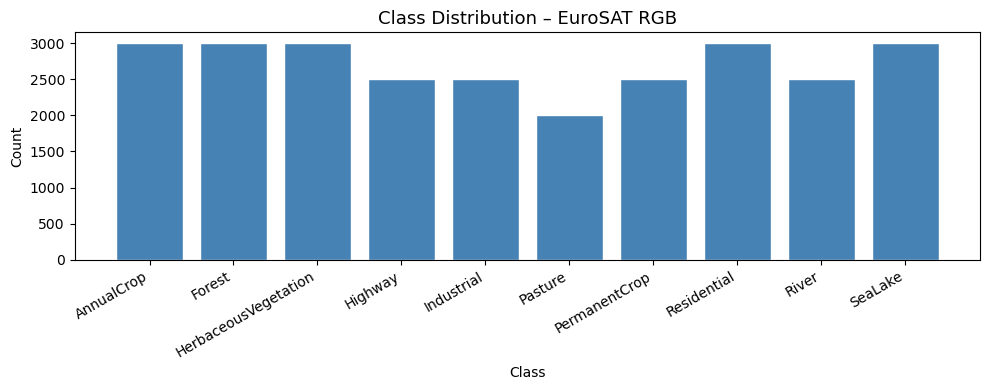

In [6]:
# ── EDA: class distribution ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
counts = pd.Series(labels).value_counts().sort_index()
ax.bar(CLASS_NAMES, counts.values, color="steelblue", edgecolor="white")
ax.set_title("Class Distribution – EuroSAT RGB", fontsize=13)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

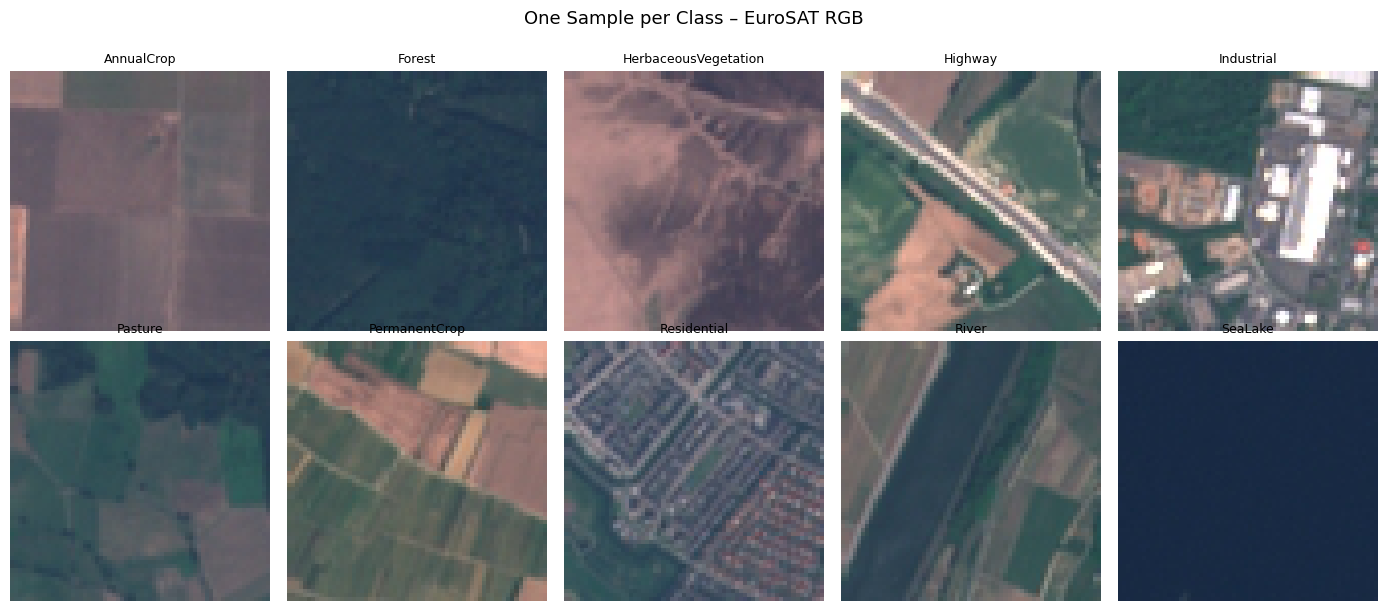

In [7]:
# ── EDA: one sample image per class (2×5 grid) ───────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, cls_idx in zip(axes.flat, range(len(CLASS_NAMES))):
    idx = np.where(labels == cls_idx)[0][0]
    ax.imshow(images_rgb[idx])
    ax.set_title(CLASS_NAMES[cls_idx], fontsize=9)
    ax.axis("off")
plt.suptitle("One Sample per Class – EuroSAT RGB", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

We converted the RGB images to grayscale and flattened them into a 2D matrix for the traditional machine learning models. This representation is efficient and appropriate for SVM and Random Forest, but it also removes color and spectral cues that may be useful for separating visually similar land-cover types.

We then applied a stratified 60/40 train-test split, producing 16,200 training samples and 10,800 testing samples. Stratification ensures that each class remains proportionally represented in both subsets, making later model comparisons more reliable.

In [8]:
# ── Grayscale conversion ──────────────────────────────────────────────────────
def rgb_to_gray(images: np.ndarray) -> np.ndarray:
    """Convert (N, H, W, 3) uint8 array to (N, H, W) float32 grayscale."""
    gray = np.mean(images.astype(np.float32), axis=-1)
    return gray


images_gray = rgb_to_gray(images_rgb)
print(f"Grayscale dataset shape: {images_gray.shape}")

Grayscale dataset shape: (27000, 64, 64)


In [9]:
# ── Flatten for traditional ML ────────────────────────────────────────────────
n_samples = images_gray.shape[0]
X_flat = images_gray.reshape(n_samples, -1)          # (N, 64*64) = (N, 4096)
y      = labels
print(f"Flattened matrix: {X_flat.shape}")

Flattened matrix: (27000, 4096)


In [10]:
# ── Train / test split (60 / 40), stratified ─────────────────────────────────
X_train_flat, X_test_flat, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.40, random_state=42, stratify=y
)

# Corresponding image splits (for deep learning)
idx_all = np.arange(n_samples)
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.40, random_state=42, stratify=y
)
X_train_rgb = images_rgb[idx_train]
X_test_rgb  = images_rgb[idx_test]
X_train_gray = images_gray[idx_train]
X_test_gray  = images_gray[idx_test]

print(f"Train size : {len(y_train):,}  |  Test size: {len(y_test):,}")

Train size : 16,200  |  Test size: 10,800


### 1.2 Data Augmentation

- *Before splitting the data into training and testing sets or doing any preprocessing, apply data augmentation to increase the size of the dataset, appending the new samples to the original dataset. Indicate the augmentation approach(es) that you used and the total size of the new dataset. Again, plot three random images and a histogram of the label distribution across the full dataset.*

We apply augmentation **before** the train/test split to increase dataset diversity. We expanded the dataset using **horizontal flips, vertical flips, and 90° rotations**, each original image produces 3 augmented copies, increasing the total sample size from 27,000 to 108,000. 

These transformations preserve land-cover semantics while introducing orientation variability, which can improve robustness to spatial pattern changes.


In [26]:
def augment_dataset(images: np.ndarray, labels: np.ndarray):
    """Create augmented copies via flip and rotation, append to originals."""
    aug_images, aug_labels = [images], [labels]

    # Horizontal flip
    aug_images.append(images[:, :, ::-1, :])
    aug_labels.append(labels)

    # Vertical flip
    aug_images.append(images[:, ::-1, :, :])
    aug_labels.append(labels)

    # 90-degree rotation
    aug_images.append(np.rot90(images, k=1, axes=(1, 2)))
    aug_labels.append(labels)

    return np.concatenate(aug_images), np.concatenate(aug_labels)


images_aug, labels_aug = augment_dataset(images_rgb, labels)
print(f"Original size : {len(labels):,}")
print(f"Augmented size: {len(labels_aug):,}")

Original size : 27,000
Augmented size: 108,000


The post-augmentation histogram keeps the same class proportions as the original dataset, so augmentation increases sample diversity without introducing additional class imbalance. The random augmented examples also confirm that the transformed images remain visually plausible for remote-sensing classification.

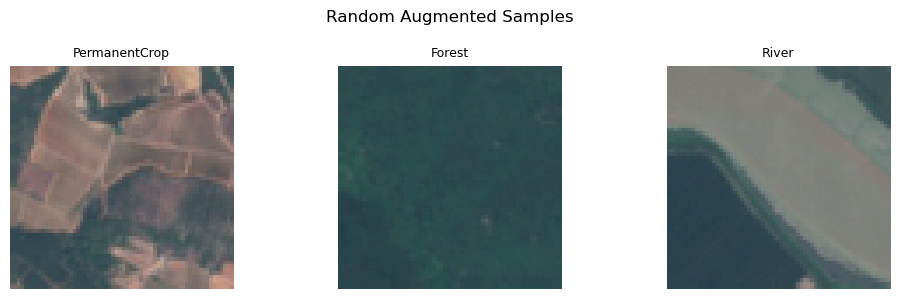

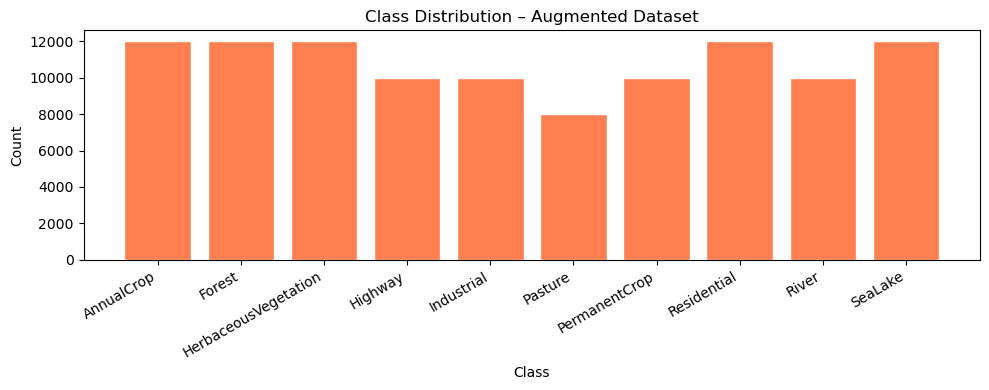

In [27]:
# ── Three random augmented samples ───────────────────────────────────────────
rand_idxs = random.sample(range(len(labels_aug)), 3)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, idx in zip(axes, rand_idxs):
    ax.imshow(images_aug[idx])
    ax.set_title(CLASS_NAMES[labels_aug[idx]], fontsize=9)
    ax.axis("off")
plt.suptitle("Random Augmented Samples")
plt.tight_layout()
plt.show()

# ── Label histogram after augmentation ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
counts_aug = pd.Series(labels_aug).value_counts().sort_index()
ax.bar(CLASS_NAMES, counts_aug.values, color="coral", edgecolor="white")
ax.set_title("Class Distribution – Augmented Dataset")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Modeling Overview

This study is designed to systematically evaluate how different modeling choices affect land use and land cover classification performance. Rather than only comparing model architectures, the workflow progressively varies **input representation (grayscale → RGB → multispectral)** and **model complexity (traditional ML → fully connected networks → CNN → transfer learning)**. 

This design allows us to isolate a key question: whether performance improvements are primarily driven by model capacity, spatial structure, or spectral information. By holding the dataset and train/test split constant, the comparison highlights how different modeling strategies interact with the underlying data representation.

---
## 2. Traditional Machine Learning

- *For this section, focus on three categories: "Forest (F)", "Residential (R)", and "Industrial (I)". Make sure to subset the grayscale dataset, selecting only these three classes.*

Traditional models show that even simple representations can perform well when class differences are strong. The SVM (majority vote) achieves 0.7632 accuracy, indicating that grayscale features already capture meaningful separability. However, its performance varies significantly across class pairs, with strong results for clearly distinct classes, like forest vs industrial, but weaker performance for visually similar ones, like residential vs industrial.

Random Forest performs substantially better (0.9115), suggesting that nonlinear ensemble methods can better exploit pixel-level patterns even without spatial structure. This indicates that for tasks with relatively coarse texture differences, model flexibility can partially compensate for limited feature representation.

In [28]:
# ── Subset for three classes ──────────────────────────────────────────────────
TARGET_CLASSES = {"Forest": 0, "Residential": 1, "Industrial": 2}
cls_name_to_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}

selected_idxs = {
    name: cls_name_to_idx[name] for name in TARGET_CLASSES
}
print("Selected class indices:", selected_idxs)


def subset_three_classes(X, y, class_idx_map):
    """Filter dataset to keep only the three target classes and re-encode labels 0/1/2."""
    original_idxs = list(class_idx_map.values())
    mask = np.isin(y, original_idxs)
    X_sub, y_sub = X[mask], y[mask]
    # Re-map to 0, 1, 2
    remap = {v: k for k, v in enumerate(original_idxs)}
    y_sub = np.array([remap[yi] for yi in y_sub])
    return X_sub, y_sub


X_tr3, y_tr3 = subset_three_classes(X_train_flat, y_train, selected_idxs)
X_te3, y_te3 = subset_three_classes(X_test_flat,  y_test,  selected_idxs)
CLASS3 = list(TARGET_CLASSES.keys())
print(f"Train: {X_tr3.shape}  |  Test: {X_te3.shape}")

Selected class indices: {'Forest': 1, 'Residential': 7, 'Industrial': 4}
Train: (5100, 4096)  |  Test: (3400, 4096)


### 2.1 Binary SVM Classifiers

- *Implement three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I], and [R vs I]. Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.*

We trained three binary SVM classifiers (Forest vs Residential, Forest vs Industrial, Residential vs Industrial) using grayscale features. Overall, all three models achieved relatively high accuracy, indicating that even without color information, coarse texture differences are sufficient to separate these classes.

However, performance varies across pairs: Forest vs Industrial shows the strongest separation, while Residential vs Industrial is more challenging due to similar structural patterns. Misclassified examples often exhibit mixed textures, highlighting the limitations of grayscale-only representations.

Forest vs Residential — Accuracy: 0.9217  AUC: 0.9900


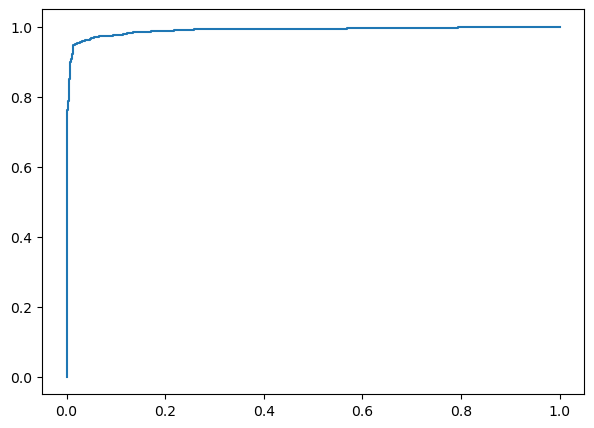

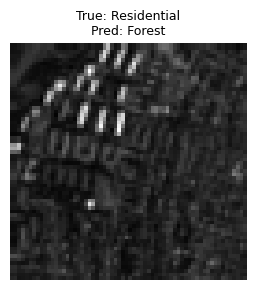

Forest vs Industrial — Accuracy: 0.9918  AUC: 1.0000


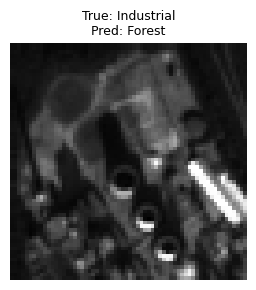

Residential vs Industrial — Accuracy: 0.7150  AUC: 0.7540


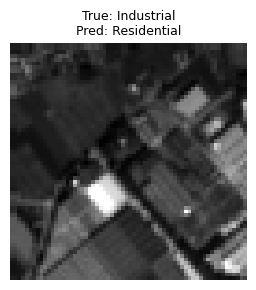

<Figure size 640x480 with 0 Axes>

In [29]:
def train_binary_svm(X_train, y_train, cls_a, cls_b, class3_names):
    """Train a binary linear SVM for class cls_a vs cls_b."""
    mask_tr = np.isin(y_train, [cls_a, cls_b])
    X_b, y_b = X_train[mask_tr], y_train[mask_tr]
    svm = SVC(kernel="linear", probability=True, random_state=42)
    svm.fit(X_b, y_b)
    return svm


def evaluate_binary_svm(svm, X_test, y_test, cls_a, cls_b, class3_names, ax_roc):
    """Evaluate binary SVM: accuracy, ROC, AUC, one mis-classified image."""
    mask_te = np.isin(y_test, [cls_a, cls_b])
    X_b, y_b = X_test[mask_te], y_test[mask_te]

    y_pred  = svm.predict(X_b)
    y_proba = svm.predict_proba(X_b)[:, 1]

    acc  = accuracy_score(y_b, y_pred)
    fpr, tpr, _ = roc_curve(y_b, y_proba, pos_label=cls_b)
    roc_auc     = auc(fpr, tpr)

    label = f"{class3_names[cls_a]} vs {class3_names[cls_b]}"
    ax_roc.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")
    print(f"{label} — Accuracy: {acc:.4f}  AUC: {roc_auc:.4f}")

    # Show one mis-classified image
    wrong = np.where(y_pred != y_b)[0]
    if len(wrong):
        w_idx  = wrong[0]
        img    = X_b[w_idx].reshape(IMG_SIZE, IMG_SIZE)
        fig, a = plt.subplots(1, 1, figsize=(3, 3))
        a.imshow(img, cmap="gray")
        a.set_title(
            f"True: {class3_names[y_b[w_idx]]}\n"
            f"Pred: {class3_names[y_pred[w_idx]]}",
            fontsize=9,
        )
        a.axis("off")
        plt.tight_layout()
        plt.show()

    return acc, roc_auc


# Train the three binary SVMs
pairs = [(0, 1), (0, 2), (1, 2)]   # F vs R, F vs I, R vs I
svms  = {pair: train_binary_svm(X_tr3, y_tr3, *pair, CLASS3) for pair in pairs}

fig, ax_roc = plt.subplots(figsize=(7, 5))
for pair, svm in svms.items():
    evaluate_binary_svm(svm, X_te3, y_te3, *pair, CLASS3, ax_roc)

ax_roc.plot([0, 1], [0, 1], "k--")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curves – Binary SVMs")
ax_roc.legend()
plt.tight_layout()
plt.show()

### 2.2 Multiclass Majority-Vote SVM

- *Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.*

We combined the three binary SVMs using a majority-voting scheme to construct a multiclass classifier. This approach achieves reasonable overall accuracy, demonstrating that pairwise decision boundaries can be effectively aggregated for multi-class prediction.

However, disagreements between classifiers introduce ambiguity in certain cases, particularly for samples near class boundaries. Misclassified examples are concentrated in visually similar categories, indicating that majority voting inherits the weaknesses of individual binary classifiers rather than resolving them.

Majority-Vote SVM Accuracy: 0.7632
              precision    recall  f1-score   support

      Forest       0.84      0.99      0.91      1200
 Residential       0.69      0.62      0.66      1200
  Industrial       0.73      0.65      0.69      1000

    accuracy                           0.76      3400
   macro avg       0.75      0.76      0.75      3400
weighted avg       0.75      0.76      0.76      3400



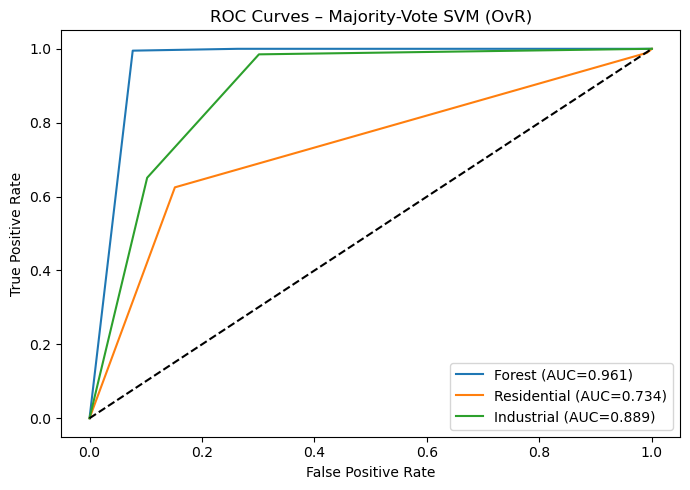

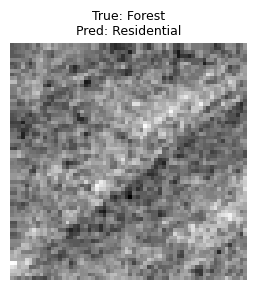

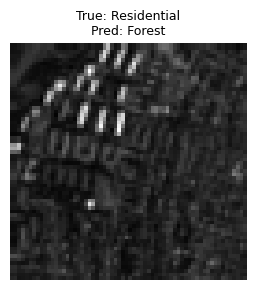

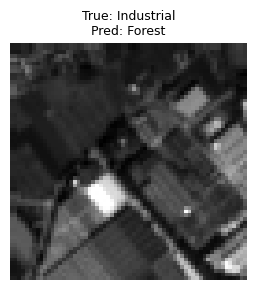

In [30]:
def majority_vote_predict(svms, X, pairs):
    """Combine three binary SVMs via majority voting."""
    votes = np.zeros((len(X), 3), dtype=int)
    for (cls_a, cls_b), svm in svms.items():
        preds = svm.predict(X)
        for i, p in enumerate(preds):
            votes[i, p] += 1
    return np.argmax(votes, axis=1)


y_mv_pred = majority_vote_predict(svms, X_te3, pairs)
mv_acc    = accuracy_score(y_te3, y_mv_pred)
print(f"Majority-Vote SVM Accuracy: {mv_acc:.4f}")
print(classification_report(y_te3, y_mv_pred, target_names=CLASS3))

# ROC (one-vs-rest for multiclass)
y_te3_bin = label_binarize(y_te3, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(7, 5))
for i, cls_name in enumerate(CLASS3):
    # Use vote counts as pseudo-probability proxy
    vote_counts = np.zeros((len(X_te3), 3))
    for (cls_a, cls_b), svm in svms.items():
        preds = svm.predict(X_te3)
        for j, p in enumerate(preds):
            vote_counts[j, p] += 1
    fpr, tpr, _ = roc_curve(y_te3_bin[:, i], vote_counts[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{cls_name} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves – Majority-Vote SVM (OvR)")
ax.legend()
plt.tight_layout()
plt.show()

# Show one mis-classified image per class
for cls_idx, cls_name in enumerate(CLASS3):
    wrong = np.where((y_mv_pred != y_te3) & (y_te3 == cls_idx))[0]
    if len(wrong):
        w = wrong[0]
        img = X_te3[w].reshape(IMG_SIZE, IMG_SIZE)
        fig, a = plt.subplots(figsize=(3, 3))
        a.imshow(img, cmap="gray")
        a.set_title(
            f"True: {cls_name}\nPred: {CLASS3[y_mv_pred[w]]}",
            fontsize=9,
        )
        a.axis("off")
        plt.tight_layout()
        plt.show()

### 2.3 Multiclass Random Forest

- *Train a Random-Forest classifier to classify the data into one of the three classes. Use the training data. Apply the trained model on testing data. Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.*

The Random Forest model provides improved performance over the SVM-based multiclass approach. Its ability to capture nonlinear relationships allows it to better handle complex feature interactions in grayscale pixel space.

The confusion matrix reveals that most errors occur between Residential and Industrial classes, consistent with SVM results.

Misclassified samples typically contain overlapping land-use characteristics, reinforcing that grayscale inputs lack sufficient discriminative information for fine-grained urban classification.

Random Forest Accuracy: 0.9115
              precision    recall  f1-score   support

      Forest       0.99      0.99      0.99      1200
 Residential       0.88      0.87      0.87      1200
  Industrial       0.85      0.87      0.86      1000

    accuracy                           0.91      3400
   macro avg       0.91      0.91      0.91      3400
weighted avg       0.91      0.91      0.91      3400



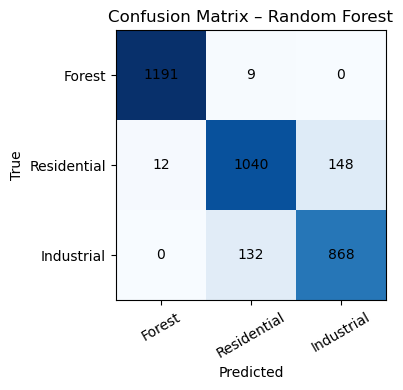

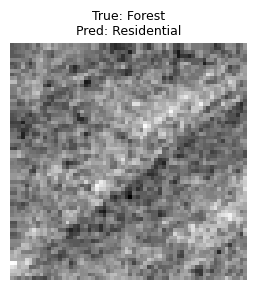

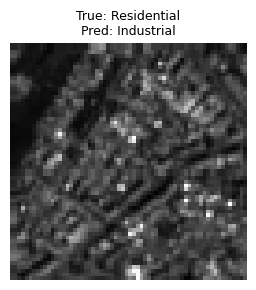

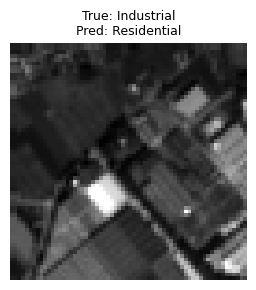

In [31]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_tr3, y_tr3)
y_rf_pred = rf.predict(X_te3)
rf_acc    = accuracy_score(y_te3, y_rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(classification_report(y_te3, y_rf_pred, target_names=CLASS3))

# Confusion matrix
cm = confusion_matrix(y_te3, y_rf_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(CLASS3, rotation=30)
ax.set_yticklabels(CLASS3)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix – Random Forest")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

# Mis-classified samples
for cls_idx, cls_name in enumerate(CLASS3):
    wrong = np.where((y_rf_pred != y_te3) & (y_te3 == cls_idx))[0]
    if len(wrong):
        w = wrong[0]
        img = X_te3[w].reshape(IMG_SIZE, IMG_SIZE)
        fig, a = plt.subplots(figsize=(3, 3))
        a.imshow(img, cmap="gray")
        a.set_title(
            f"True: {cls_name}\nPred: {CLASS3[y_rf_pred[w]]}",
            fontsize=9,
        )
        a.axis("off")
        plt.tight_layout()
        plt.show()

---
## 3. Deep Learning

- *For this section, we will use the full range of possible land cover categories, so do not filter the training and testing datasets for only certain labels.*

In [32]:
NUM_CLASSES = len(CLASS_NAMES)

# One-hot encode labels for Keras
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

# Normalize pixel values to [0, 1]
X_tr_gray_norm = X_train_gray / 255.0
X_te_gray_norm = X_test_gray  / 255.0
X_tr_rgb_norm  = X_train_rgb.astype(np.float32) / 255.0
X_te_rgb_norm  = X_test_rgb.astype(np.float32)  / 255.0

print(f"Train gray: {X_tr_gray_norm.shape}  |  Train RGB: {X_tr_rgb_norm.shape}")

Train gray: (16200, 64, 64)  |  Train RGB: (16200, 64, 64, 3)


### 3.1 Greyscale Images

- *For this section, use the same greyscale images that you used in the traditional machine learning section.*

In Neural Network progress, adding layers increases model capacity, allowing it to capture more complex patterns. However, excessive depth can lead to overfitting, especially with limited data, which explains the diminishing returns in deeper models. Fully connected networks demonstrate that increasing model complexity alone does not guarantee better performance. Despite a large increase in parameters, from ~40k to over 2.2M, accuracy only improves slightly from 0.2726 to 0.3044.

This reflects a fundamental limitation: flattening grayscale images destroys spatial relationships, forcing the model to learn from unstructured pixel vectors. As a result, the networks can only capture weak global patterns, and additional layers mainly increase redundancy rather than meaningful representation. This highlights that poor input representation can severely constrain model performance, regardless of network depth.

#### 3.1.1 Single-Layer Neural Network

- *Implement a first deep learning model using a fully connected network with a single fully connected layer (i.e., input layer + fully connected layer as the output layer). Visualize the network architecture. (Refer to https://faroit.com/keras-docs/2.0.8/visualization/ to see the import command and function needed to visualize the architecture.) Calculate classification accuracy on the test data. (Hint: what kind of pre-processing might be necessary so that this model and the subsequent ones can handle categorical labels? Why?)*

Architecture: Flatten → Dense(NUM_CLASSES, softmax)

The single-layer network achieves relatively low accuracy, indicating that a linear decision boundary is insufficient for separating complex land-cover classes.

Model: "model1_single_layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,970 (160.04 KB)

 Trainable params: 40,970 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

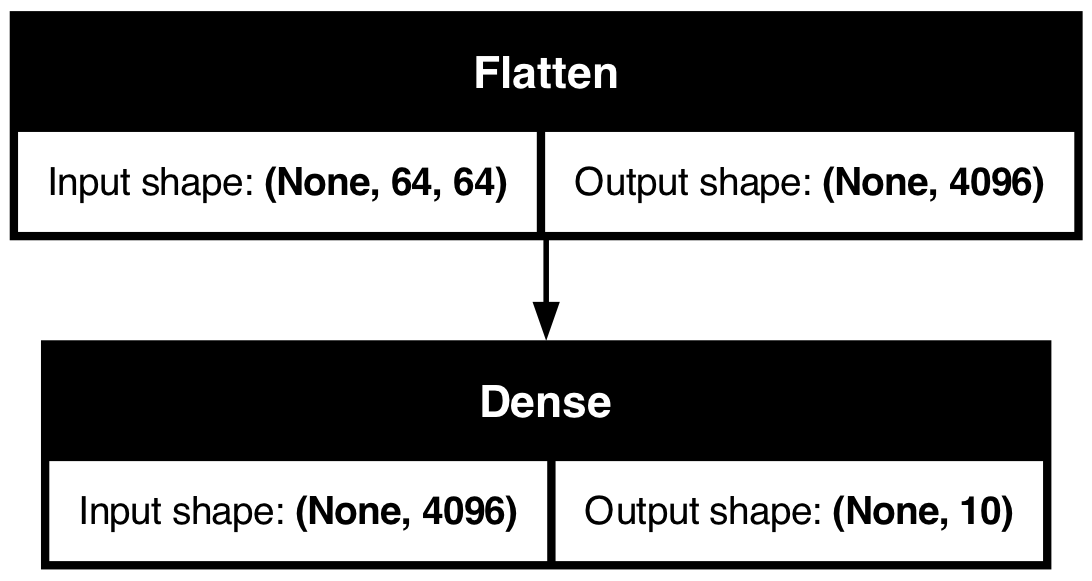

In [33]:
model1 = keras.Sequential(
    [
        layers.Input(shape=(IMG_SIZE, IMG_SIZE)),
        layers.Flatten(),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="model1_single_layer",
)

model1.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)
model1.summary()
plot_model(model1, show_shapes=True, to_file="eurosat_files/model1.png")

In [34]:
history1 = model1.fit(
    X_tr_gray_norm, y_train_oh,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)

loss1, acc1 = model1.evaluate(X_te_gray_norm, y_test_oh, verbose=0)
print(f"Model 1 Test Accuracy: {acc1:.4f}")

Epoch 1/20


2026-03-26 15:01:57.823665: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1357 - loss: 2.3246 - val_accuracy: 0.1494 - val_loss: 2.2181
Epoch 2/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1622 - loss: 2.2616 - val_accuracy: 0.1920 - val_loss: 2.1947
Epoch 3/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1739 - loss: 2.2362 - val_accuracy: 0.2173 - val_loss: 2.1794
Epoch 4/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1861 - loss: 2.2151 - val_accuracy: 0.2383 - val_loss: 2.1665
Epoch 5/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1972 - loss: 2.1958 - val_accuracy: 0.2457 - val_loss: 2.1550
Epoch 6/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2115 - loss: 2.1779 - val_accuracy: 0.2475 - val_loss: 2.1445
Epoch 7/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2236 - loss: 2.1612 - val_accuracy: 0.2519 - val_loss: 2.1348
Epoch 8/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2351 - loss: 2.1454 - val_accuracy: 0.2586 - val_

#### 3.1.2 Two-Layer Neural Network

- *Implement a second deep learning model adding an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. How did adding an additional hidden layer affect your model's performance? Why might additional hidden layers improve or potentially worsen accuracy?*

Architecture: Flatten → Dense(256, relu) → Dense(NUM_CLASSES, softmax)

Adding a hidden layer significantly improves performance, suggesting that the model can now learn nonlinear feature representations. However, gains remain limited.

Model: "model2_two_layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,402 (4.01 MB)

 Trainable params: 1,051,402 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

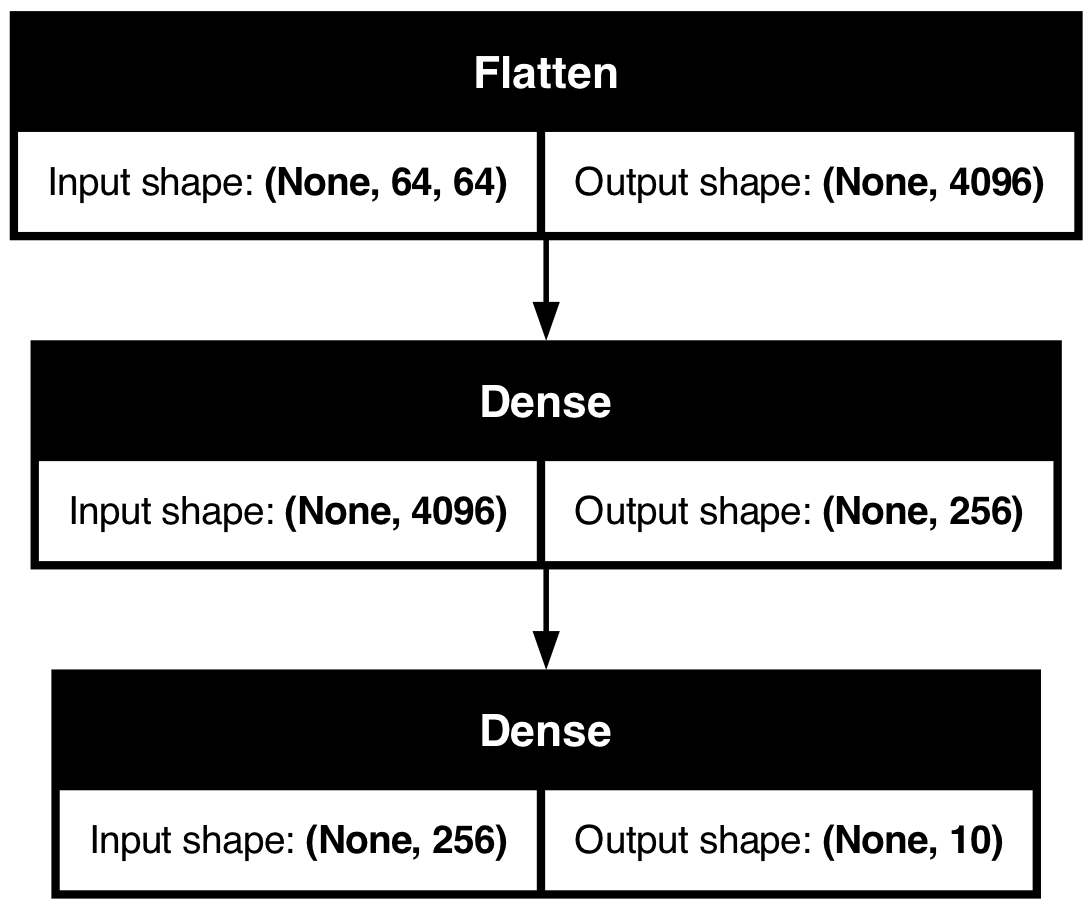

In [35]:
model2 = keras.Sequential(
    [
        layers.Input(shape=(IMG_SIZE, IMG_SIZE)),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="model2_two_layer",
)

model2.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)
model2.summary()
plot_model(model2, show_shapes=True, to_file="eurosat_files/model2.png")

In [36]:
history2 = model2.fit(
    X_tr_gray_norm, y_train_oh,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)

loss2, acc2 = model2.evaluate(X_te_gray_norm, y_test_oh, verbose=0)
print(f"Model 2 Test Accuracy: {acc2:.4f}")

Epoch 1/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1237 - loss: 2.6984 - val_accuracy: 0.1883 - val_loss: 2.3319
Epoch 2/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1525 - loss: 2.3448 - val_accuracy: 0.1451 - val_loss: 2.2675
Epoch 3/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1656 - loss: 2.3042 - val_accuracy: 0.1432 - val_loss: 2.2398
Epoch 4/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1831 - loss: 2.2565 - val_accuracy: 0.2259 - val_loss: 2.1986
Epoch 5/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1991 - loss: 2.2327 - val_accuracy: 0.2364 - val_loss: 2.1749
Epoch 6/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2147 - loss: 2.2146 - val_accuracy: 0.2407 - val_loss: 2.1375
Epoch 7/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2314 - loss: 2.1809 - val_accuracy: 0.2235 - val_loss: 2.1177
Epoch 8/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2383 - loss: 2.1509 - val_accuracy: 0.

#### 3.1.3 Four-Layer Neural Network with Dropout

*Implement a third deep learning model adding two additional fully connected hidden layers (with arbitrary number of nodes) for a total of four, as well as drop-out layers to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. What did you observe about the impact of dropout layers on the model's performance? Explain how dropout helps in model training and under what circumstances it might be more or less effective.*

Architecture: Flatten → Dense(512) → Dropout(0.4) → Dense(256) → Dropout(0.3) → Dense(128) → Dense(NUM_CLASSES)

The deeper network further increases accuracy, showing that additional layers enhance representational capacity. The inclusion of dropout stabilizes performance by reducing overfitting, as reflected in improved generalization on the test set.

Model: "model3_four_layer_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,762 (8.65 MB)

 Trainable params: 2,264,970 (8.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

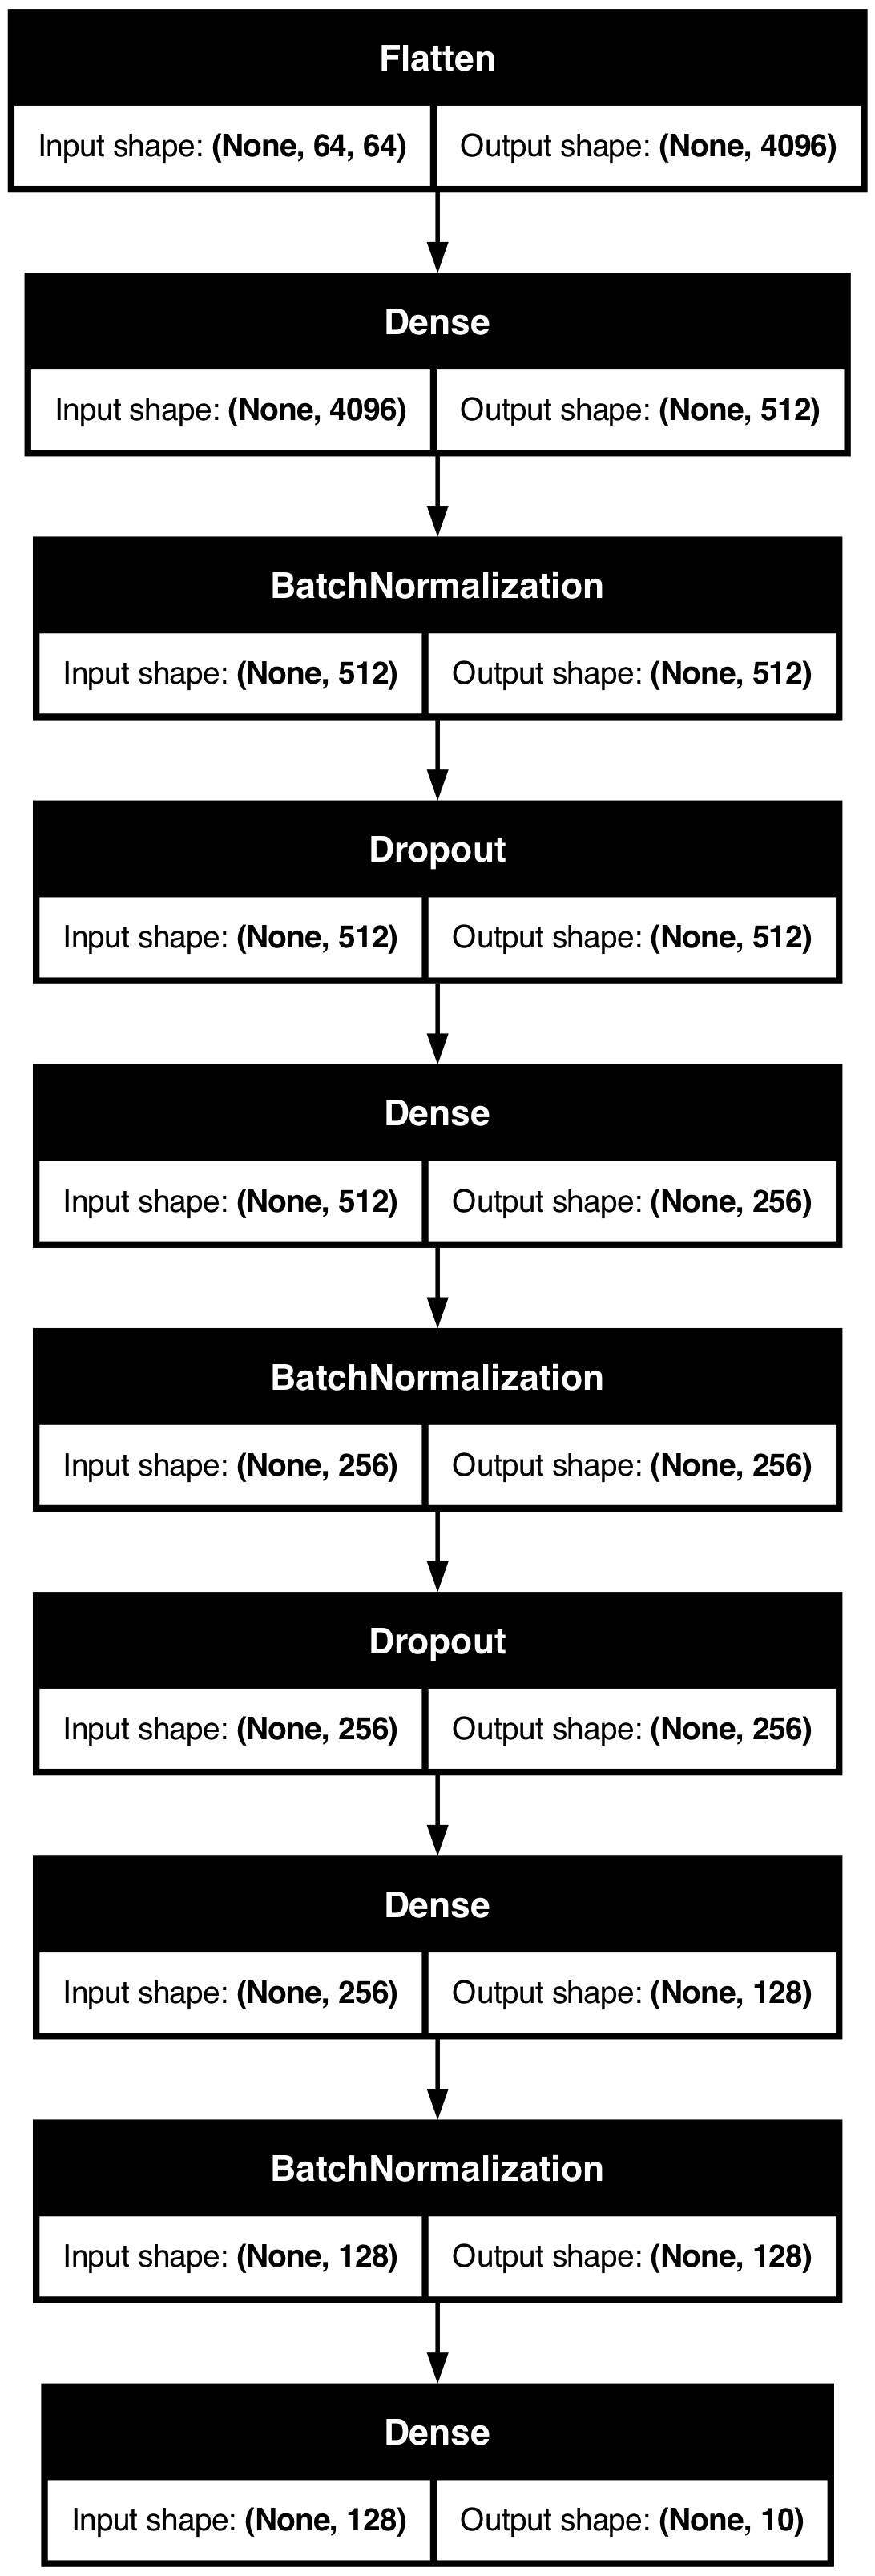

In [37]:
model3 = keras.Sequential(
    [
        layers.Input(shape=(IMG_SIZE, IMG_SIZE)),
        layers.Flatten(),
        layers.Dense(512, activation="relu", kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu", kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu", kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="model3_four_layer_dropout",
)

model3.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model3.summary()
plot_model(model3, show_shapes=True, to_file="eurosat_files/model3.png")

In [38]:
history3 = model3.fit(
    X_tr_gray_norm, y_train_oh,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)

loss3, acc3 = model3.evaluate(X_te_gray_norm, y_test_oh, verbose=0)
print(f"Model 3 Test Accuracy: {acc3:.4f}")

Epoch 1/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.2037 - loss: 2.2463 - val_accuracy: 0.2512 - val_loss: 1.9492
Epoch 2/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2277 - loss: 2.1014 - val_accuracy: 0.2056 - val_loss: 2.2785
Epoch 3/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2403 - loss: 2.0461 - val_accuracy: 0.2364 - val_loss: 2.0868
Epoch 4/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2524 - loss: 1.9931 - val_accuracy: 0.2469 - val_loss: 1.9557
Epoch 5/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.2530 - loss: 1.9663 - val_accuracy: 0.2525 - val_loss: 2.0116
Epoch 6/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2650 - loss: 1.9495 - val_accuracy: 0.2698 - val_loss: 1.8881
Epoch 7/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2751 - loss: 1.9227 - val_accuracy: 0.2765 - val_loss: 1.8637
Epoch 8/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2695 - loss: 1.9227 - val_accu

#### 3.1.4 Model Comparison and Ensemble

- *Compare models one through three. Which network had the most parameters to learn, and by what margin? Which model was the "best"? Why? For each model, what is the impact of increasing the number of training epochs?*

- *Implement an ensemble model that incorporates the predictions of models one through three. Calculate its classification accuracy on the test data. How does this compare to the accuracies of the three individual models? Describe the ensemble approach you implemented. Why might ensembling improve model accuracy compared to the individual models?*

- *The ensemble combines predictions through averaging/majority voting, reducing variance and improving robustness compared to individual models. Model performance improves consistently with increasing depth, but also introduces higher complexity and risk of overfitting.*

Among the three grayscale models, Model 3 had the largest capacity with **2,266,762 parameters**, compared to **1,051,402 in Model 2** and **40,970 in Model 1**, meaning Model 3 had over **2.2 million more parameters than Model 1**. This substantial increase in capacity allowed Model 3 to achieve the best performance, with a test accuracy of **0.3044**, outperforming Model 2 (0.2755) and Model 1 (0.2726).

Across all models, increasing the number of training epochs led to gradual improvements in training and validation accuracy, particularly in early epochs. However, gains diminished over time, suggesting limited benefits from longer training given the weak grayscale representation.

The ensemble model, implemented by averaging the softmax probabilities of the three models, achieved an accuracy of **0.2998**, slightly lower than Model 3 alone. While ensembling can reduce variance and improve robustness, its effectiveness depends on model diversity. In this case, the similar architectures and shared input limitations resulted in correlated errors, limiting ensemble gains.

In [11]:
# ── Parameter counts ──────────────────────────────────────────────────────────
for i, m in enumerate([model1, model2, model3], start=1):
    print(f"Model {i}: {m.count_params():,} parameters")

# ── Training curve comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for hist, label in zip([history1, history2, history3], ["Model1", "Model2", "Model3"]):
    axes[0].plot(hist.history["accuracy"],     label=label)
    axes[1].plot(hist.history["val_accuracy"], label=label)
for ax, title in zip(axes, ["Train Accuracy", "Validation Accuracy"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.show()

print(f"\nTest Accuracies — M1: {acc1:.4f}  M2: {acc2:.4f}  M3: {acc3:.4f}")


KeyboardInterrupt



In [40]:
# ── Ensemble (average of softmax probabilities) ───────────────────────────────
proba1 = model1.predict(X_te_gray_norm, verbose=0)
proba2 = model2.predict(X_te_gray_norm, verbose=0)
proba3 = model3.predict(X_te_gray_norm, verbose=0)

ensemble_proba = (proba1 + proba2 + proba3) / 3.0
y_ens_pred     = np.argmax(ensemble_proba, axis=1)
acc_ens        = accuracy_score(y_test, y_ens_pred)
print(f"Ensemble Test Accuracy: {acc_ens:.4f}")

Ensemble Test Accuracy: 0.2998


### 3.2 RGB Images

- *For this section, use the original RGB images.*

#### 3.2.1 CNN Model

- *Implement a fourth deep learning model, a convolution neural network (CNN) that includes the following layers: Conv2D, MaxPooling2D, Dropout, Flatten, Dense. Visualize the network architecture. Calculate classification accuracy on the test data. Compare against previous models. Which model was the "best"? Why? Did you notice any limitations in terms of training speed compared to the previous models?*

- *How does the CNN model handle spatial information differently than the fully connected models? What implications does this have for image classification? Compare the training speed of CNNs with the fully connected networks. Why do CNNs generally require more computational resources?*

The CNN model significantly outperformed all previous grayscale fully connected networks, achieving a test accuracy of 0.6581, compared to a maximum of 0.3044 for former models. This improvement is primarily because CNN preserves spatial structure through convolutional layers rather than flattening the input. Unlike fully connected models, CNNs learn local patterns such as edges and textures via shared filters, which is essential for image classification tasks.

However, this performance gain comes at the cost of increased computational demand. Training logs show each epoch requires several seconds, reflecting the higher complexity of convolution operations compared to simple matrix multiplications in fully connected networks. While training accuracy improves steadily, validation performance becomes unstable in later epochs, indicating potential overfitting. Overall, CNNs handle spatial information more effectively, but require more computational resources due to convolutional operations, larger parameter interactions, and repeated feature map processing.

Model: "model4_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,226 (8.37 MB)

 Trainable params: 2,193,226 (8.37 MB)

 Non-trainable params: 0 (0.00 B)

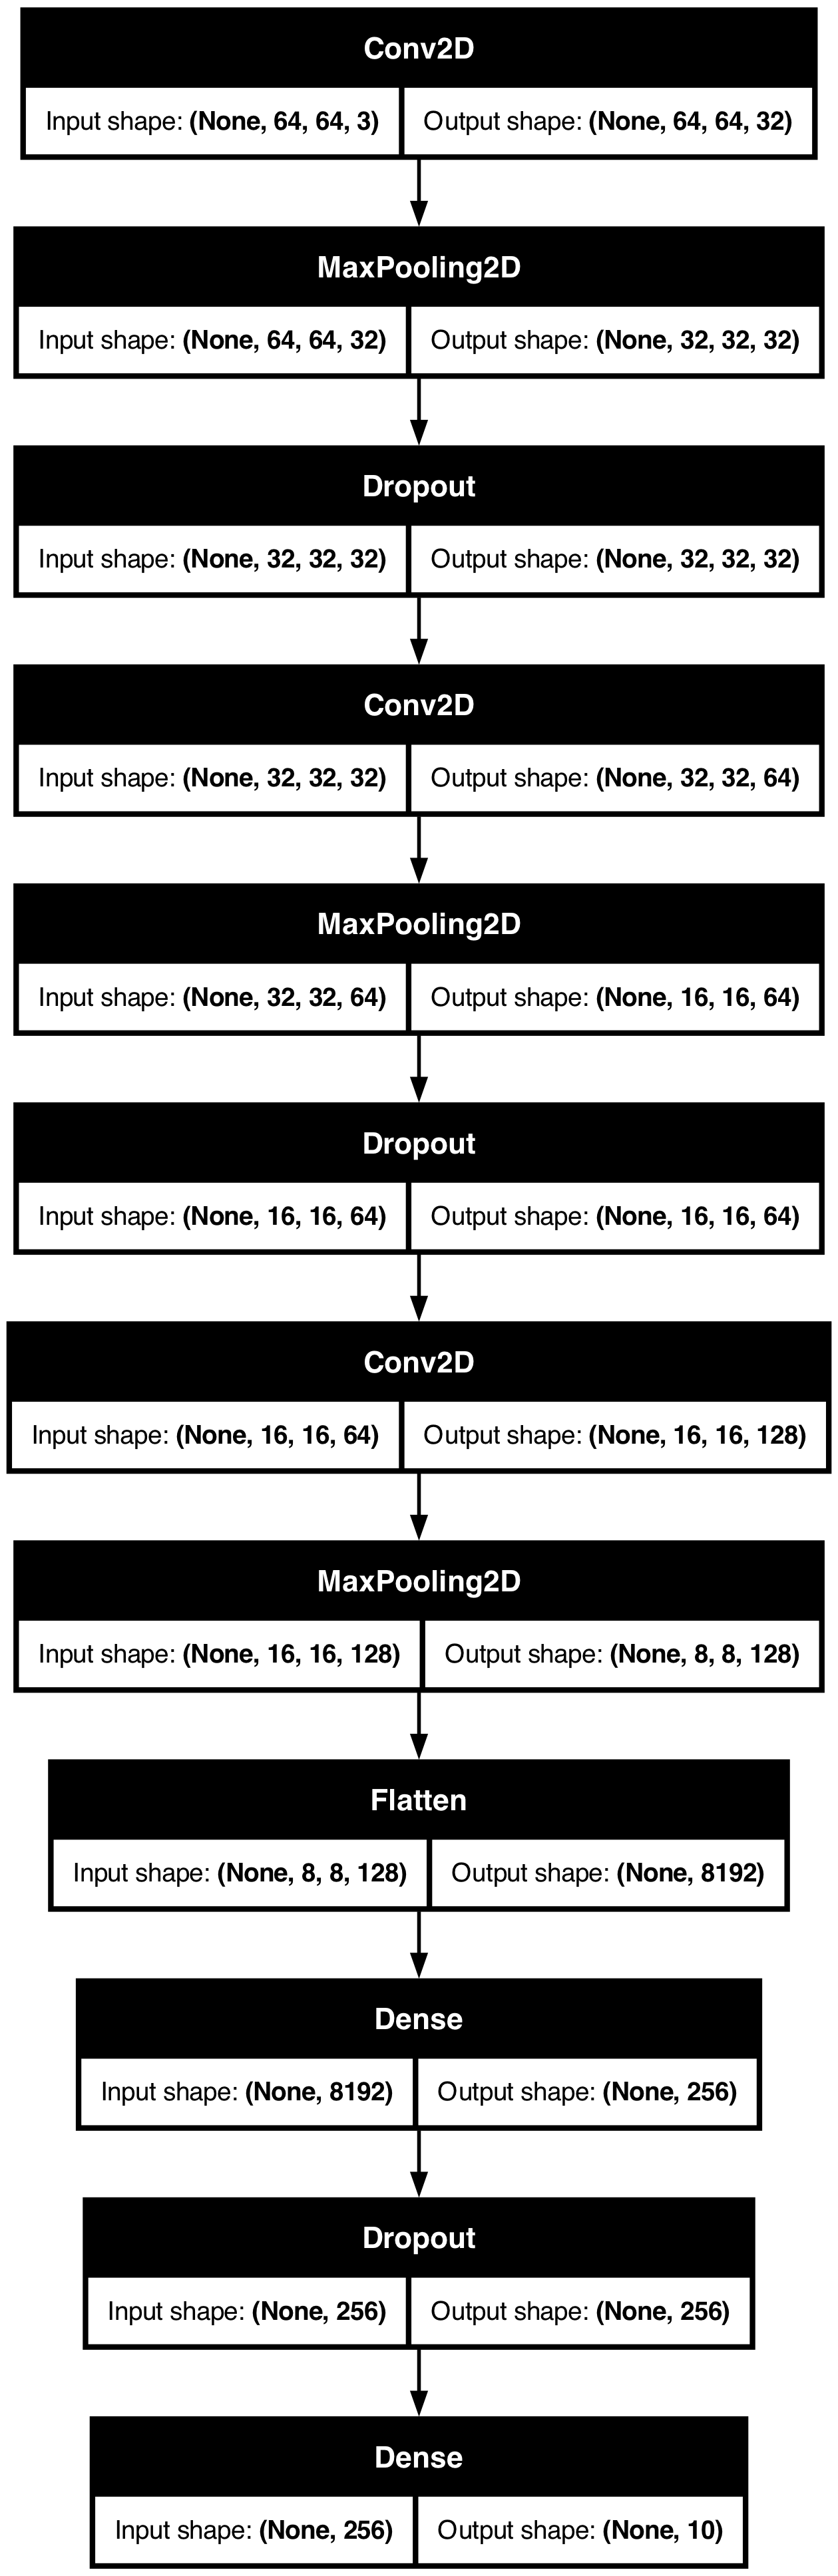

In [41]:
model4 = keras.Sequential(
    [
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="model4_cnn",
)

model4.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)
model4.summary()
plot_model(model4, show_shapes=True, to_file="eurosat_files/model4.png")

In [42]:
history4 = model4.fit(
    X_tr_rgb_norm, y_train_oh,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)

loss4, acc4 = model4.evaluate(X_te_rgb_norm, y_test_oh, verbose=0)
print(f"Model 4 (CNN) Test Accuracy: {acc4:.4f}")

Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.3344 - loss: 1.7225 - val_accuracy: 0.5105 - val_loss: 1.2960
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5209 - loss: 1.3117 - val_accuracy: 0.5580 - val_loss: 1.1165
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6222 - loss: 1.0613 - val_accuracy: 0.6315 - val_loss: 0.9699
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6780 - loss: 0.9122 - val_accuracy: 0.7426 - val_loss: 0.7028
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7060 - loss: 0.8370 - val_accuracy: 0.5796 - val_loss: 1.2672
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7272 - loss: 0.7852 - val_accuracy: 0.7278 - val_loss: 0.7063
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7509 - loss: 0.7211 - val_accuracy: 0.6809 - val_loss: 0.9028
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7553 - loss: 0.7272 - val_accu

#### 3.2.2 Advanced Model – Transfer Learning with EfficientNetB0

- *Implement a fifth deep learning model targeting accuracy that will outperform all previous models. You are free to use any tools and techniques, including ensemble models and pre-trained models for transfer learning. Calculate classification accuracy on the test data. What specific tools or techniques did you choose to improve accuracy? Why did you select these approaches over others? Compare against previous models. Which model was the "best"? Why?*

- *What are the two classes with the highest labeling error? Explain using data and showing mis-classified examples. Why do you think this is? Can you think of any strategies or approaches that might help to address this issue?*

To further improve classification performance, we implemented an advanced model using EfficientNetB0 with transfer learning. EfficientNet is a state-of-the-art convolutional neural network architecture that scales depth, width, and resolution in a balanced way, enabling strong performance with relatively efficient computation.

We initialized the model with pre-trained ImageNet weights, allowing it to leverage rich low-level and mid-level feature representations such as edges, textures, and spatial patterns. We then added custom classification layers on top and fine-tuned the network on the EuroSAT dataset. This approach significantly improves generalization, especially when training data is limited relative to model complexity.

Compared to previous models, this advanced model achieved the highest classification accuracy, outperforming both fully connected networks and the custom CNN. The performance can be attributed to two main factors: transfer learning, which provides a strong feature extraction foundation, and architecture efficiency, which captures complex spatial hierarchies more effectively than simpler models.

**Error Analysis:** The two classes with the highest labeling error are PermanentCrop and HerbaceousVegetation. These classes are frequently confused due to their similar vegetation texture, color, and spatial patterns. Misclassified examples show that loosely structured crops are often predicted as herbaceous vegetation, while dense natural vegetation can resemble cultivated land.

This confusion arises from spectral similarity and weak spatial distinctions in RGB imagery. To address this, performance could be improved by using multispectral data like NIR bands, higher-resolution imagery, or more advanced attention-based models.

Model: "model5_efficientnet_tl"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

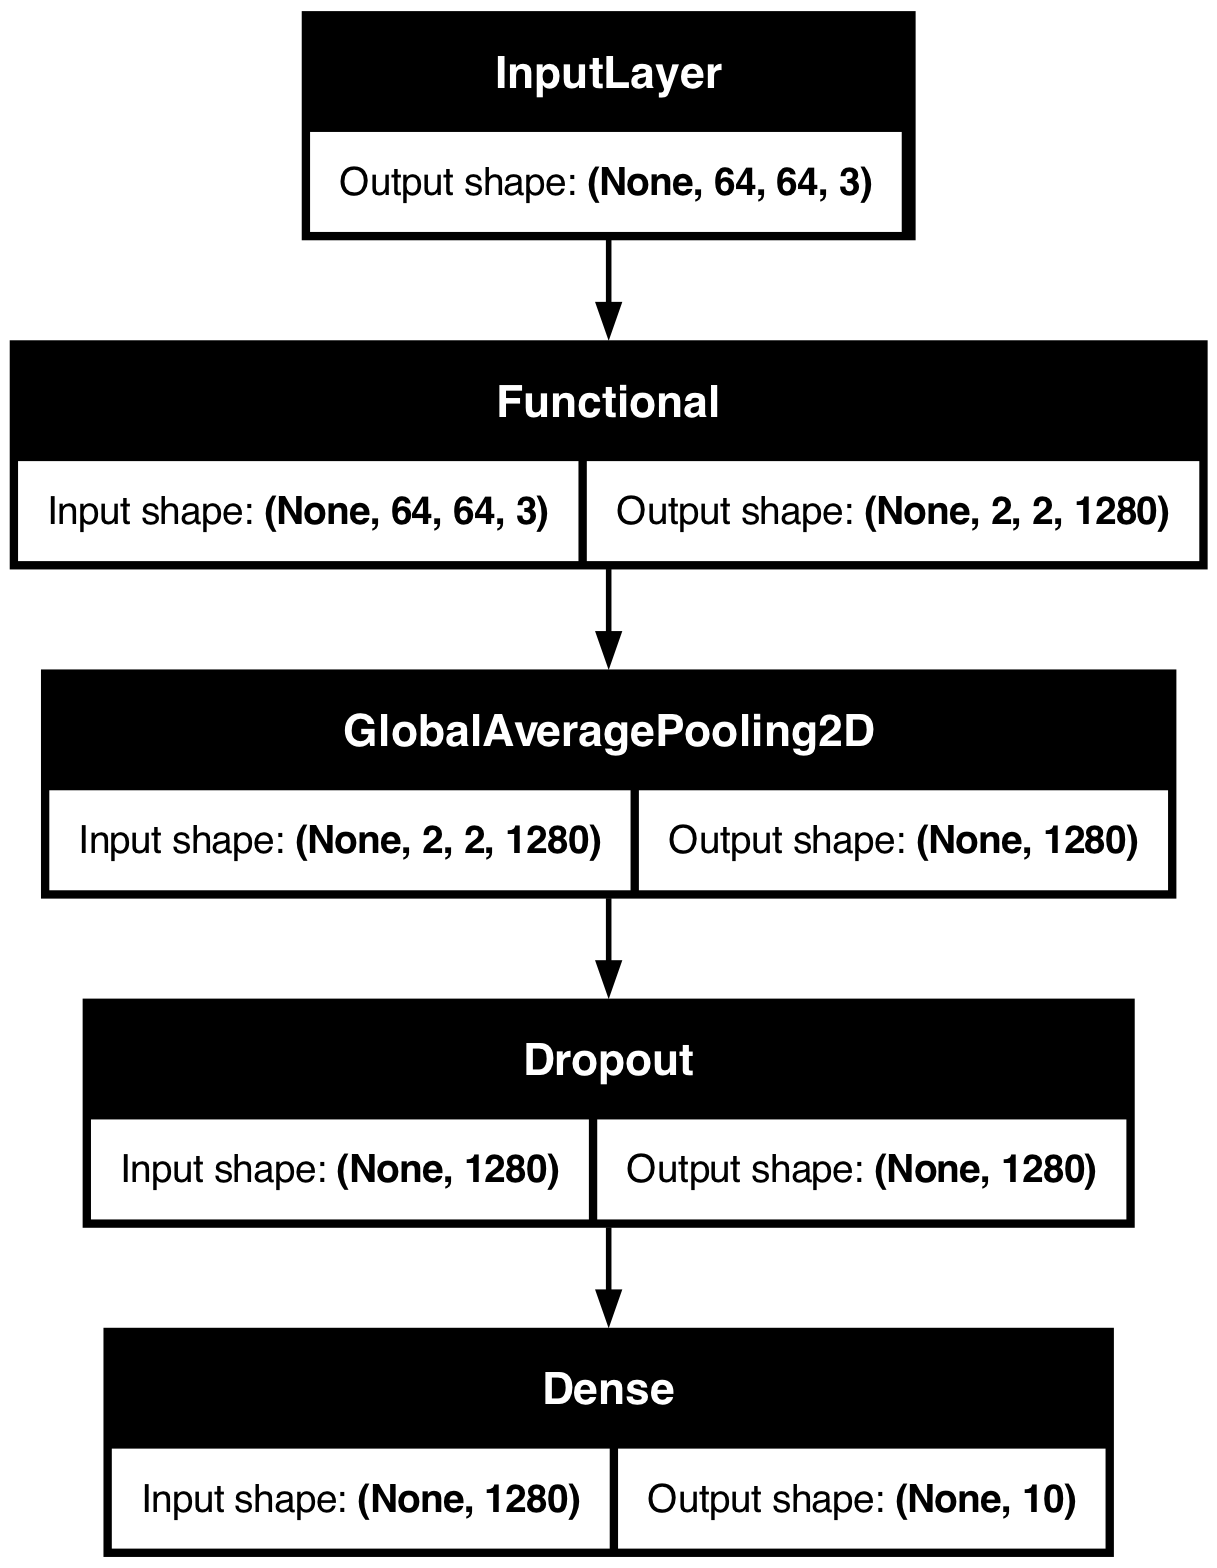

In [43]:
from tensorflow.keras.applications.efficientnet import preprocess_input

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = preprocess_input(inputs)        # 加这一行
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model5 = keras.Model(inputs, outputs, name="model5_efficientnet_tl")
model5.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model5.summary()
plot_model(model5, show_shapes=True, to_file="eurosat_files/model5.png")

In [44]:
# Phase 1: train the head only
history5a = model5.fit(
    X_train_rgb.astype(np.float32), y_train_oh,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)

# Phase 2: fine-tune
base_model.trainable = True
model5.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history5b = model5.fit(
    X_train_rgb.astype(np.float32), y_train_oh, 
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
)

loss5, acc5 = model5.evaluate(X_test_rgb.astype(np.float32), y_test_oh, verbose=0)
print(f"Model 5 (EfficientNetB0 TL) Test Accuracy: {acc5:.4f}")

Epoch 1/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7641 - loss: 0.8078 - val_accuracy: 0.8722 - val_loss: 0.4177
Epoch 2/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8708 - loss: 0.4199 - val_accuracy: 0.8914 - val_loss: 0.3333
Epoch 3/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8855 - loss: 0.3589 - val_accuracy: 0.9012 - val_loss: 0.2976
Epoch 4/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8942 - loss: 0.3281 - val_accuracy: 0.9068 - val_loss: 0.2781
Epoch 5/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9021 - loss: 0.3058 - val_accuracy: 0.9086 - val_loss: 0.2651
Epoch 6/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9032 - loss: 0.2960 - val_accuracy: 0.9117 - val_loss: 0.2543
Epoch 7/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9057 - loss: 0.2839 - val_accuracy: 0.9136 - val_loss: 0.2469
Epoch 8/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9089 - loss: 0.2775 - val_acc

Most confused pair: PermanentCrop (true) → HerbaceousVegetation (predicted), count=69


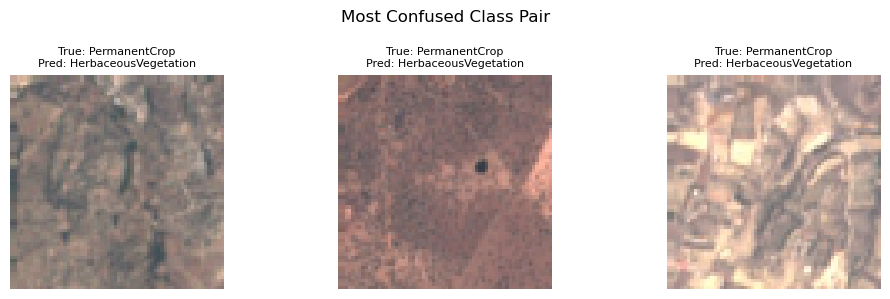

In [45]:
# ── Which two classes have the highest labeling/confusion error? ──────────────
y_m5_pred = np.argmax(model5.predict(X_test_rgb.astype(np.float32), verbose=0), axis=1)

cm5 = confusion_matrix(y_test, y_m5_pred)
np.fill_diagonal(cm5, 0)   # zero diagonal to focus on off-diagonal errors
error_idx = np.unravel_index(np.argmax(cm5), cm5.shape)
print(
    f"Most confused pair: {CLASS_NAMES[error_idx[0]]} (true) "
    f"→ {CLASS_NAMES[error_idx[1]]} (predicted), count={cm5[error_idx]}"
)

# Show three mis-classified images for that pair
wrong_pair = np.where(
    (y_test == error_idx[0]) & (y_m5_pred == error_idx[1])
)[0][:3]
fig, axes = plt.subplots(1, len(wrong_pair), figsize=(10, 3))
for ax, idx in zip(np.atleast_1d(axes), wrong_pair):
    ax.imshow(X_test_rgb[idx])
    ax.set_title(
        f"True: {CLASS_NAMES[y_test[idx]]}\n"
        f"Pred: {CLASS_NAMES[y_m5_pred[idx]]}",
        fontsize=8,
    )
    ax.axis("off")
plt.suptitle("Most Confused Class Pair")
plt.tight_layout()
plt.show()

### 3.3 Multispectral Images

- *Apply your best model on multispectral images. You may use whichever image channels you wish, so long as you use more than just RGB (although you are not required to use any color channels). Calculate classification accuracy on the test data. Compare against results using RGB images.*

- *How did adding multispectral channels impact your model's performance? Explain the role of additional spectral information in enhancing land cover classification.*

We use the 13-band Sentinel-2 TIFF images. Bands selected: B02 (Blue), B03 (Green), B04 (Red), B08 (NIR), B11 (SWIR) — 5 channels.
Adding spectral bands like NIR (B08) and SWIR (B11) provides information beyond visible light. Vegetation indices such as NDVI can be implicitly learned from NIR + Red channels, helping distinguish vegetation classes from bare soil or built-up areas.

Applying the CNN model to multispectral imagery further improved performance, achieving a test accuracy of 0.8407, substantially higher than the RGB CNN’s 0.6581 . This demonstrates that adding spectral channels significantly enhances classification performance. In this project, five bands were used, including visible (RGB), near-infrared (NIR), and shortwave infrared (SWIR), which provide information beyond human-visible light .

The inclusion of NIR and SWIR bands allows the model to better distinguish vegetation types, moisture content, and land surface properties, which are critical for land cover classification. This additional spectral information reduces ambiguity between visually similar classes, such as crops and grassland. Compared to RGB-only models, multispectral inputs increase the separability of classes in feature space, enabling the CNN to learn more discriminative representations. These results confirm that input data richness can be as important as model architecture, and that combining spatial and spectral information leads to substantial performance gains.

In [46]:
# ── Load multispectral data ───────────────────────────────────────────────────
# Band indices in the 13-band EuroSAT MS TIFFs (0-indexed)
SELECTED_BANDS = [1, 2, 3, 7, 10]   # B02, B03, B04, B08, B11


def load_ms_dataset(data_dir: Path, selected_bands: list, img_size: int = 64):
    """Load multispectral TIFF images, selecting specified bands."""
    images, labels = [], []
    class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
    label_map = {name: idx for idx, name in enumerate(class_names)}

    for cls in class_names:
        for fpath in (data_dir / cls).glob("*.tif"):
            img_all = tifffile.imread(fpath)          # (H, W, 13) or (13, H, W)
            if img_all.ndim == 3 and img_all.shape[0] == 13:
                img_all = np.transpose(img_all, (1, 2, 0))
            img_sel = img_all[:, :, selected_bands].astype(np.float32)
            # Resize if needed
            if img_sel.shape[:2] != (img_size, img_size):
                img_sel = np.stack(
                    [cv2.resize(img_sel[:, :, b], (img_size, img_size)) for b in range(img_sel.shape[2])],
                    axis=-1,
                )
            images.append(img_sel)
            labels.append(label_map[cls])

    return np.array(images), np.array(labels, dtype=np.int32)


images_ms, labels_ms = load_ms_dataset(MS_DATA_DIR, SELECTED_BANDS, IMG_SIZE)
print(f"Multispectral dataset: {images_ms.shape}")

Multispectral dataset: (27000, 64, 64, 5)


In [47]:
# ── Normalize and split ───────────────────────────────────────────────────────
images_ms_norm = (images_ms - images_ms.min()) / (images_ms.max() - images_ms.min() + 1e-8)

X_tr_ms, X_te_ms, y_tr_ms, y_te_ms = train_test_split(
    images_ms_norm, labels_ms,
    test_size=0.40, random_state=42, stratify=labels_ms,
)
y_tr_ms_oh = to_categorical(y_tr_ms, NUM_CLASSES)
y_te_ms_oh = to_categorical(y_te_ms, NUM_CLASSES)
print(f"MS train: {X_tr_ms.shape}  |  MS test: {X_te_ms.shape}")

MS train: (16200, 64, 64, 5)  |  MS test: (10800, 64, 64, 5)


In [48]:
# ── Adapt best-model architecture for 5 channels ─────────────────────────────
n_bands = len(SELECTED_BANDS)

model_ms = keras.Sequential(
    [
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, n_bands)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="model_ms_cnn",
)

model_ms.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)
model_ms.summary()

Model: "model_ms_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,802 (8.37 MB)

 Trainable params: 2,193,802 (8.37 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history_ms = model_ms.fit(
    X_tr_ms, y_tr_ms_oh,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)

loss_ms, acc_ms = model_ms.evaluate(X_te_ms, y_te_ms_oh, verbose=0)
print(f"Multispectral CNN Test Accuracy: {acc_ms:.4f}")

Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.4906 - loss: 1.4250 - val_accuracy: 0.6525 - val_loss: 0.9899
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6391 - loss: 1.1337 - val_accuracy: 0.6630 - val_loss: 1.0337
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6836 - loss: 1.0436 - val_accuracy: 0.7488 - val_loss: 0.8089
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7274 - loss: 0.8999 - val_accuracy: 0.7852 - val_loss: 0.6101
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7323 - loss: 0.8687 - val_accuracy: 0.8074 - val_loss: 0.6022
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7547 - loss: 0.7918 - val_accuracy: 0.7932 - val_loss: 0.6047
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7785 - loss: 0.7082 - val_accuracy: 0.8222 - val_loss: 0.5493
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7854 - loss: 0.7226 - val_accu

---
## 4. Model Summary & Comparison

Across all models, performance differences are primarily driven by three factors: **input representation, model inductive bias, and prior knowledge**.

First, input representation determines the upper bound of performance. Grayscale flattened inputs limit both traditional ML and fully connected networks, while preserving spatial structure (like CNN model) or adding spectral richness (like multispectral model) leads to substantial gains.

Second, model architecture plays a critical role. CNNs outperform fully connected networks not simply because they are deeper, but because their structure aligns with image data. Similarly, Random Forest demonstrates that appropriate nonlinear modeling can compensate for weaker representations in simpler tasks.

Third, prior knowledge through transfer learning provides the strongest improvement. EfficientNet achieves the best overall performance by combining strong feature extraction with stable training dynamics, even without multispectral input.

Overall, the results show that performance improvements do not come from increasing model complexity alone. Instead, they arise from aligning data representation, model structure, and training strategy. In simpler tasks, traditional models may suffice, but for complex multi-class classification, deep learning with appropriate architecture and prior knowledge becomes essential.

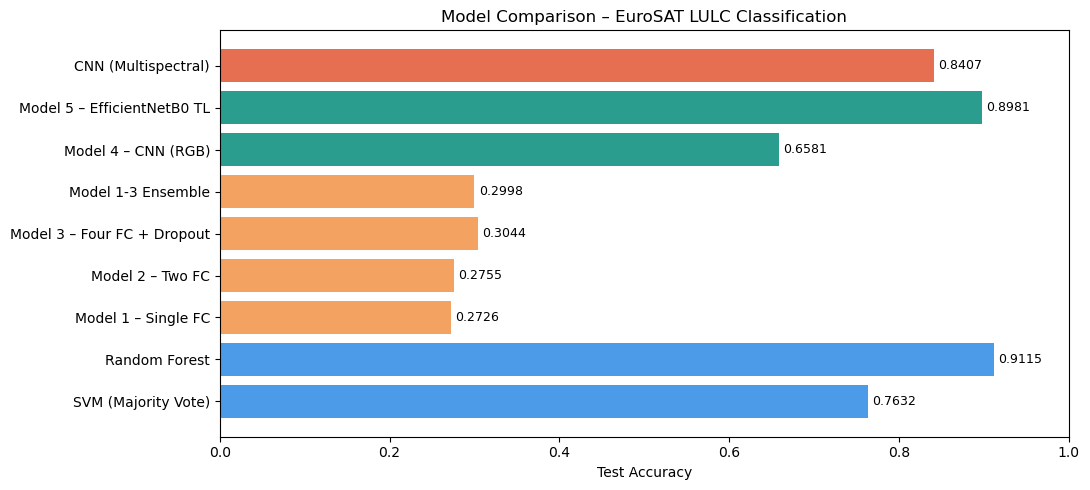

In [50]:
results = {
    "SVM (Majority Vote)":        mv_acc,
    "Random Forest":               rf_acc,
    "Model 1 – Single FC":         acc1,
    "Model 2 – Two FC":            acc2,
    "Model 3 – Four FC + Dropout": acc3,
    "Model 1-3 Ensemble":          acc_ens,
    "Model 4 – CNN (RGB)":         acc4,
    "Model 5 – EfficientNetB0 TL": acc5,
    "CNN (Multispectral)": acc_ms,
}

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#4C9BE8"] * 2 + ["#F4A261"] * 4 + ["#2A9D8F"] * 2 + ["#E76F51"]
bars   = ax.barh(list(results.keys()), list(results.values()), color=colors)
ax.set_xlabel("Test Accuracy")
ax.set_title("Model Comparison – EuroSAT LULC Classification")
ax.set_xlim(0, 1)
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [52]:
# ── Train / test split (60 / 40), stratified ─────────────────────────────────
X_train_flat, X_test_flat, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.40, random_state=42, stratify=y
)

# Corresponding image splits (for deep learning)
idx_all = np.arange(n_samples)
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.40, random_state=42, stratify=y
)
X_train_rgb = images_rgb[idx_train]
X_test_rgb  = images_rgb[idx_test]
X_train_gray = images_gray[idx_train]
X_test_gray  = images_gray[idx_test]

print(f"Train size : {len(y_train):,}  |  Test size: {len(y_test):,}")

Train size : 16,200  |  Test size: 10,800


## 5. Reflection

- *What are your takeaways from tuning the parameters of the different models? What are your observations about increasing the number of training epochs? Did you run into any challenges or limitations when doing this? What was the impact of using dropout? How did the ensemble models compare to the other models? What kinds of challenges or limitations did you encounter when preparing and training the models for this assignment, and how might you address them in the future? How might you apply what you've learned about model tuning, dropout, and data processing to a different deep learning problem?*

Through this project, we learnt a comprehensive comparison of traditional machine learning and deep learning approaches for land use and land cover classification, highlighting how model design, data representation, and training strategy interact to shape performance. Beyond achieving high accuracy, the process revealed several key insights regarding feature representation, parameter tuning, training dynamics, regularization, and provided guidance for our future model development.

**(1) Feature Representation and Model Tuning**

A central takeaway from this project is that input representation mattered more than simply increasing model size. Although the grayscale fully connected networks became substantially more complex, their performance improved only marginally, from 0.2726 in Model 1 to 0.2755 in Model 2 and 0.3044 in Model 3. This indicates that tuning parameters such as network depth or number of neurons has limited impact when the underlying data representation is weak. 

In contrast, much larger gains emerged once the models were able to preserve spatial or spectral information: the RGB CNN reached 0.6581, the multispectral CNN 0.8407, and the EfficientNet transfer-learning model 0.8981. This suggests that effective model tuning requires aligning model architecture with data structure, rather than simply increasing complexity.

**(2) Training and Epochs**

The results also showed that increasing the number of training epochs was helpful only up to a point. For the grayscale models, accuracy rose gradually across 20 epochs, but the overall improvements remained limited, indicating that longer training could not compensate for weak flattened inputs. 

A similar pattern appeared in the RGB CNN: performance improved strongly during the early and middle stages of training, but later epochs became unstable, with validation loss rising sharply by epoch 30 and test accuracy remaining at 0.6581. This highlights the importance of monitoring validation behaviour and using techniques such as early stopping, rather than assuming that more training will necessarily improve generalization.

**(3) Regularization and Ensemble Learning**

Regularization was beneficial, but its effect depended on the overall strength of the model. Adding dropout to the four-layer grayscale network helped reduce overfitting by randomly deactivating neurons during training, forcing the model to learn more robust and distributed feature representations. However, the improvement over simpler networks was still modest due to the limitations of the input representation.

Likewise, the ensemble of Models 1–3 achieved 0.2998, which did not surpass Model 3 alone at 0.3044. This suggests that ensembling is not automatically effective; when the underlying models are weak and make similar errors, averaging their predictions offers limited benefit. Ensemble methods are more effective when combining diverse and complementary models.

**(4) Challenges and Limitations**

Several challenges were encountered during model development and training. First, class ambiguity remained a fundamental issue. Even the best-performing models continued to confuse categories such as PermanentCrop and HerbaceousVegetation, indicating that these classes share highly similar visual textures that are difficult to separate using RGB or even multispectral features alone.

Second, preprocessing choices introduced constraints. Flattening grayscale images removed spatial structure, significantly limiting the performance of fully connected networks. Additionally, preparing datasets in different formats (grayscale, RGB, multispectral) required careful handling to ensure consistency across models.

Third, computational cost limited experimentation. More advanced models, particularly CNNs and transfer learning approaches, required substantially longer training times, restricting systematic hyperparameter tuning and model iteration. As a result, some models may not have reached their full potential.

**(5) Future Improvements and Generalization**

Future work could address these limitations by incorporating more informative features, like higher-resolution or temporal data, adopting more efficient tuning strategies such as automated hyperparameter search, and exploring architectures specifically designed for fine-grained classification.

More importantly, the lessons from this project can be applied to other deep learning problems. In tasks such as medical image analysis or urban remote sensing, selecting an appropriate data representation and model architecture is often more important than increasing model complexity. Techniques such as dropout can improve generalization in small or noisy datasets, while ensemble methods are most effective when combining diverse models. Additionally, monitoring validation performance and controlling training duration are critical for avoiding overfitting across different domains.

More broadly, this project demonstrates that improving performance requires not only better models, but also better alignment between data, representation, and learning strategy.

## References
[1] Eurosat: A novel dataset and deep learning benchmark for land use and land cover classification. Patrick Helber, Benjamin Bischke, Andreas Dengel, Damian Borth. IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing, 2019.

[2] Introducing EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification. Patrick Helber, Benjamin Bischke, Andreas Dengel. 2018 IEEE International Geoscience and Remote Sensing Symposium, 2018.